In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_stable = pd.read_csv("../data/clean/datos_preprocesados_clean.csv")

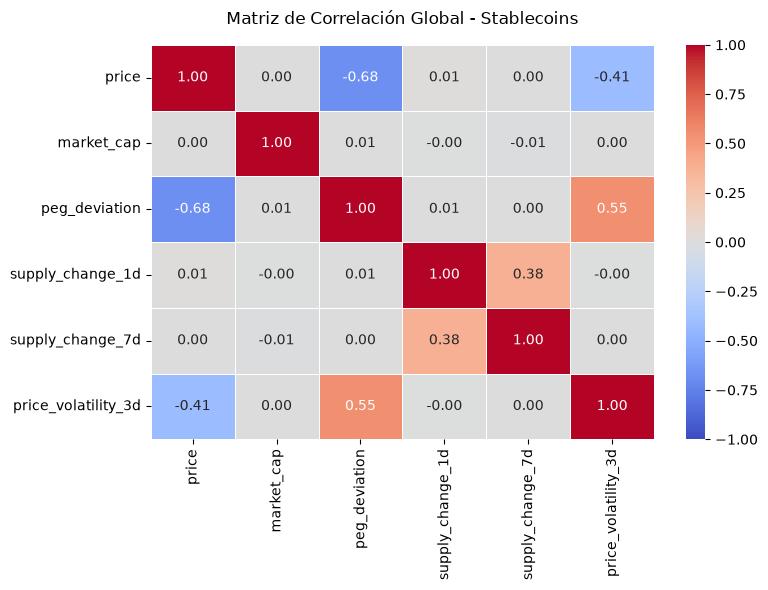

In [3]:
# 1. Panorama General: Heatmap de Correlación

plt.figure(figsize=(8, 6))
# Filtramos solo numéricas
num_cols_stable = ['price', 'market_cap', 'peg_deviation', 'supply_change_1d', 'supply_change_7d', 'price_volatility_3d']
sns.heatmap(df_stable[num_cols_stable].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación Global - Stablecoins', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_63506/2909501225.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stable, x='stablecoin', y='peg_deviation', ax=axes[0], palette='Set2')
/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_63506/2909501225.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stable, x='stablecoin', y='price_volatility_3d', ax=axes[1], palette='Set2')


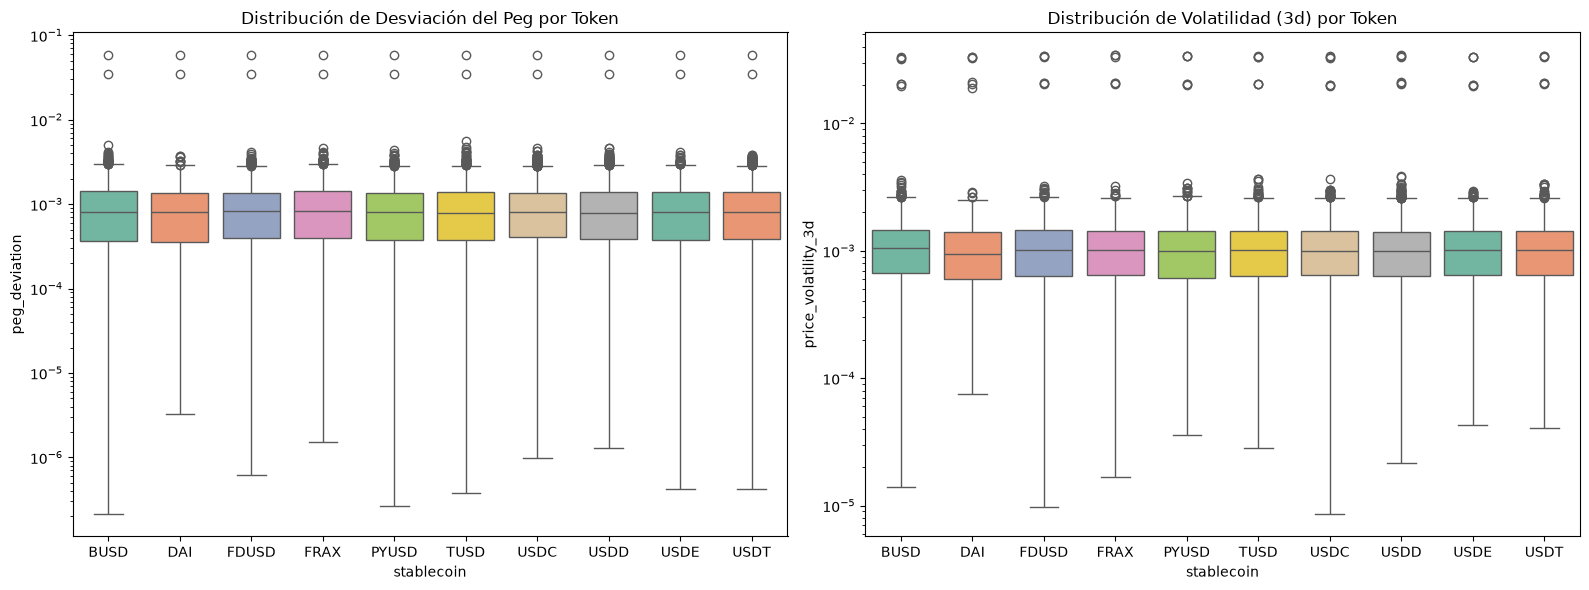

In [6]:
# 2. Categórica vs Numérica: Boxplots por Stablecoin
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Peg Deviation (Escala logarítmica opcional si USDD/FRAX deforman el gráfico)
sns.boxplot(data=df_stable, x='stablecoin', y='peg_deviation', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Desviación del Peg por Token')
axes[0].set_yscale('log') # Usamos escala logarítmica porque las desviaciones suelen ser milimétricas excepto en crisis

# Boxplot Volatilidad a 3 días
sns.boxplot(data=df_stable, x='stablecoin', y='price_volatility_3d', ax=axes[1], palette='Set2')
axes[1].set_title('Distribución de Volatilidad (3d) por Token')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

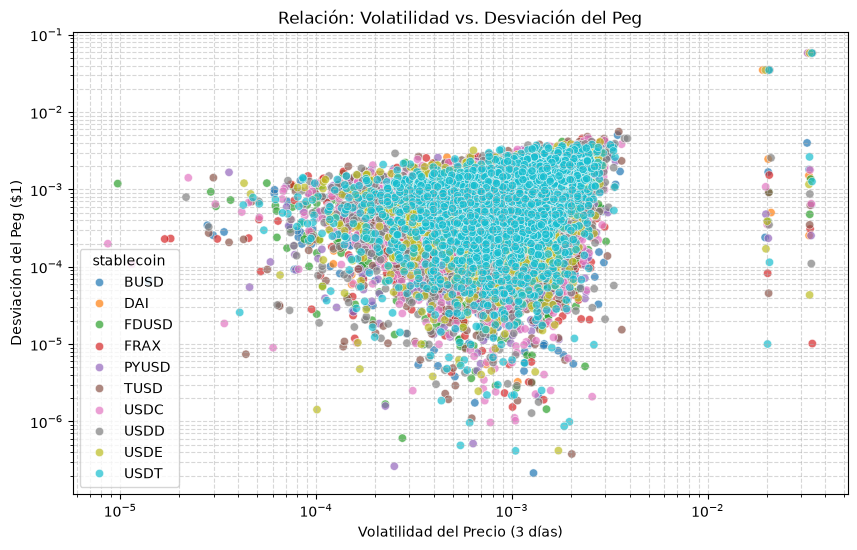

In [7]:
# =========================================================================
# 3. Numérica vs Numérica: Scatter Plot Clave
# =========================================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_stable, x='price_volatility_3d', y='peg_deviation', hue='stablecoin', alpha=0.7)
plt.title('Relación: Volatilidad vs. Desviación del Peg')
plt.xlabel('Volatilidad del Precio (3 días)')
plt.ylabel('Desviación del Peg ($1)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

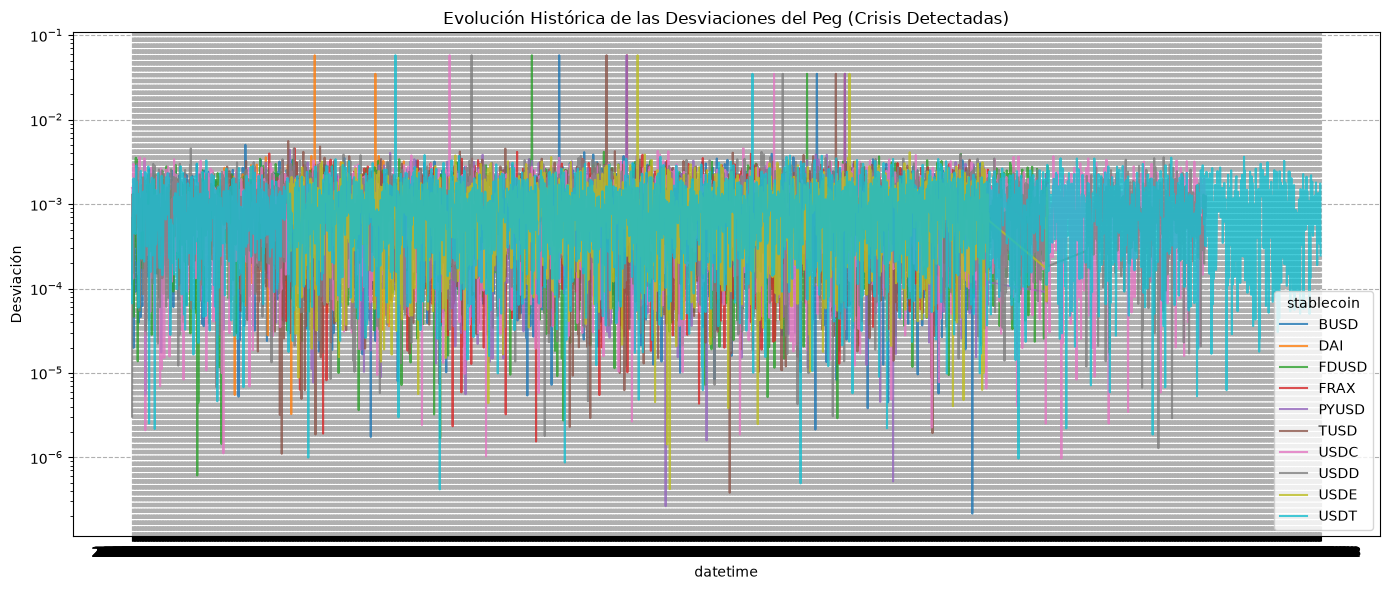

In [8]:
# =========================================================================
# 4. Evolución Temporal Bivariada
# =========================================================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_stable, x='datetime', y='peg_deviation', hue='stablecoin', alpha=0.8)
plt.title('Evolución Histórica de las Desviaciones del Peg (Crisis Detectadas)')
plt.ylabel('Desviación')
plt.yscale('log')
plt.grid(True, ls='--')
plt.tight_layout()
plt.show()